# Example of the aitlas toolbox in the context of multi class image classification

## Import the required packages

In [ ]:
from aitlas.datasets import So2SatDataset
from aitlas.models import VisionTransformer
from aitlas.transforms import ResizeCenterCropFlipHVToTensor, ResizeCenterCropToTensor, ResizeRandomCropFlipHVToTensor
from aitlas.utils import image_loader

## Load the dataset

In [ ]:
dataset_config = {
    "h5_file": "/home/dragik/data/So2Sat/training.h5"
}
dataset = So2SatDataset(dataset_config)
print(f"Total number of patches: {len(dataset)}")

Total number of patches: 352366


## Show images from the dataset

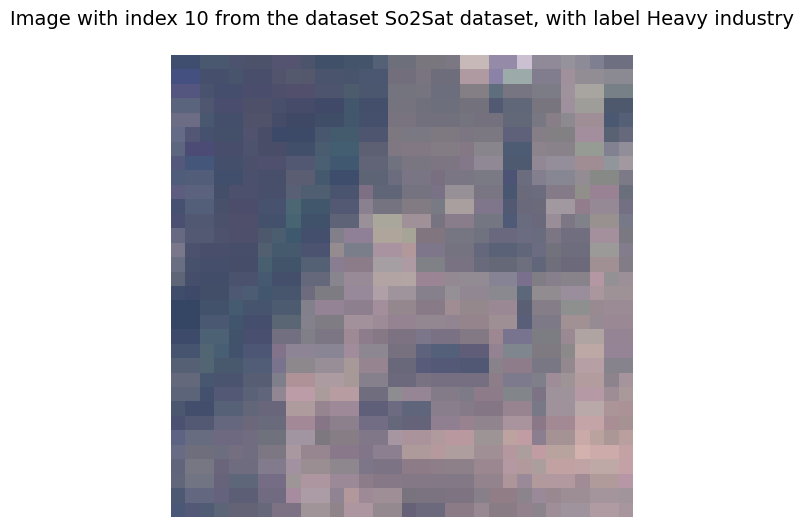

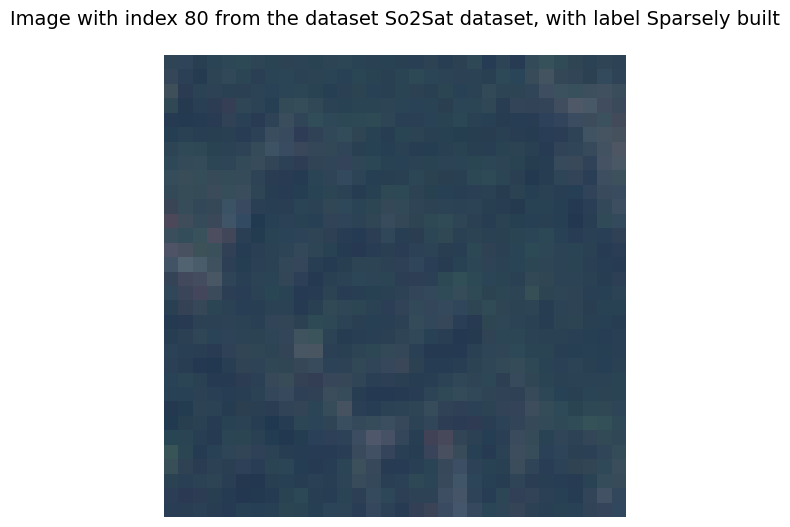

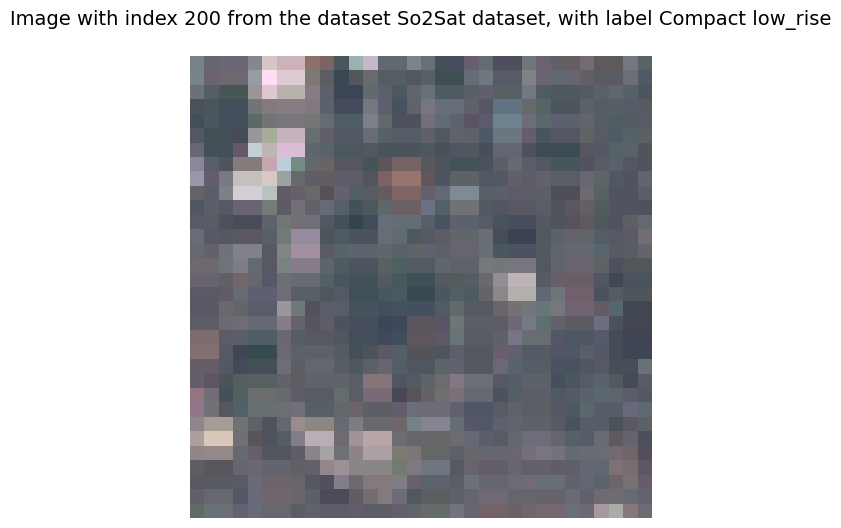

In [6]:
fig1 = dataset.show_image(10)
fig2 = dataset.show_image(80)
fig3 = dataset.show_image(200)

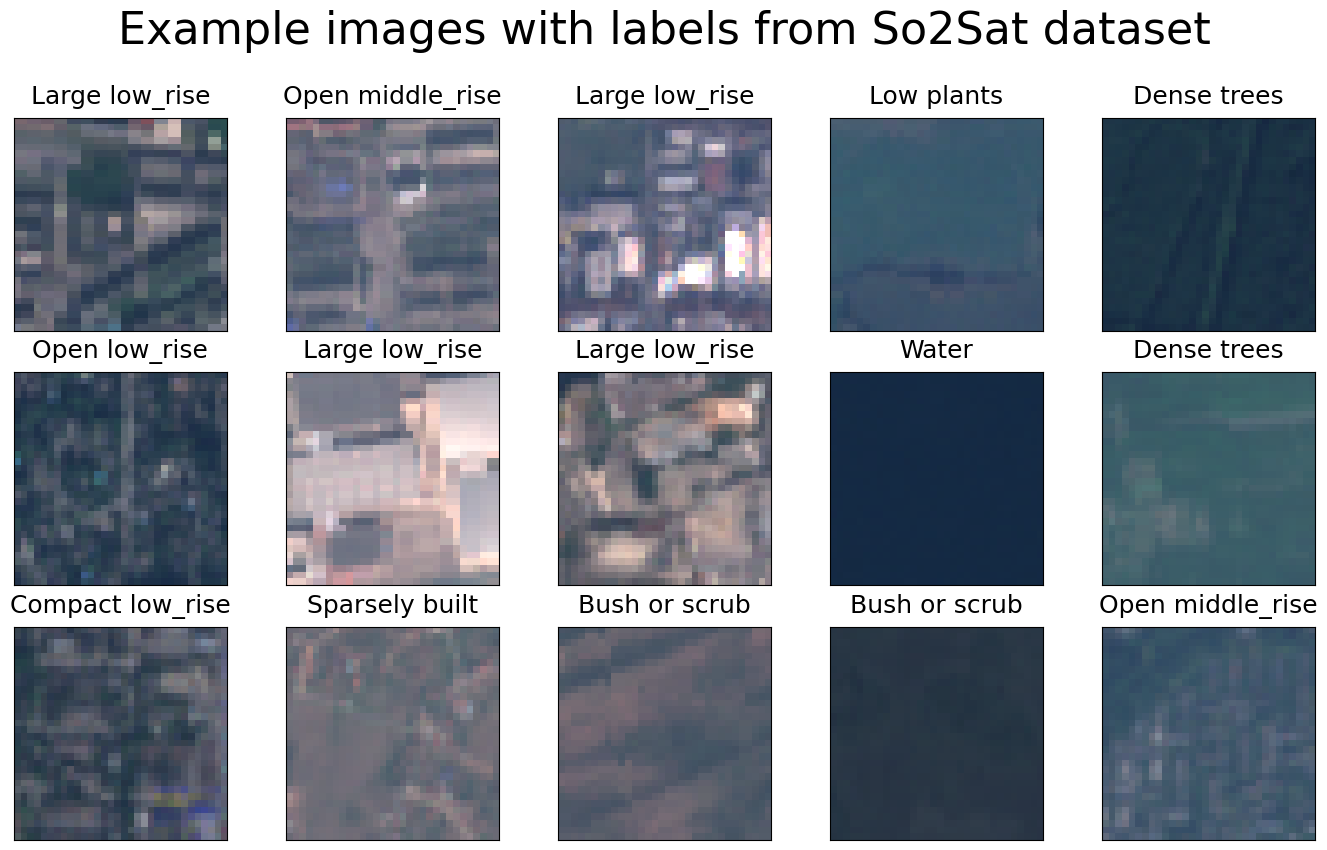

In [37]:
fig4 = dataset.show_batch(15)

## Inspect the data

In [40]:
dataset.data_distribution_table()

,Label,Count
0,Compact high_rise,5068.0
1,Compact middle_rise,24431.0
2,Compact low_rise,31693.0
3,Open high_rise,8651.0
4,Open middle_rise,16493.0
5,Open low_rise,35290.0
6,Lightweight low_rise,3269.0
7,Large low_rise,39326.0
8,Sparsely built,13584.0
9,Heavy industry,11954.0


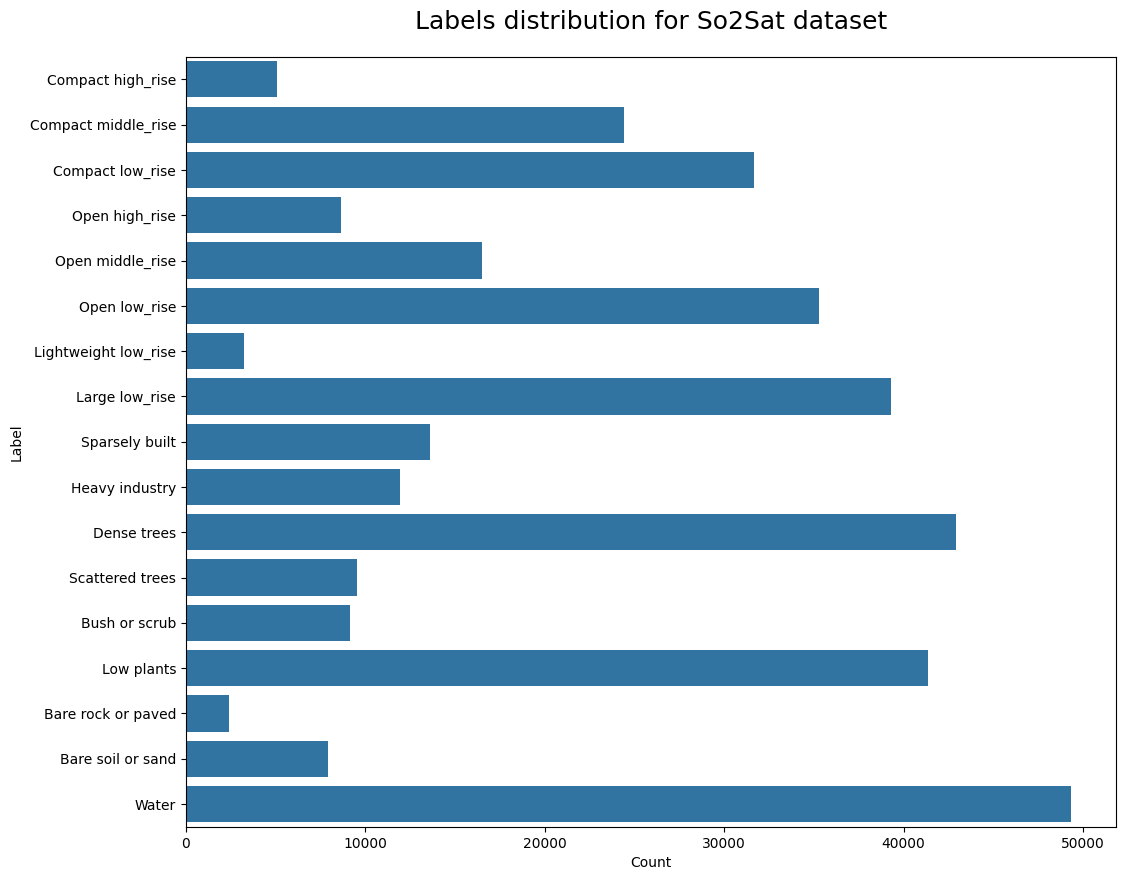

In [41]:
fig = dataset.data_distribution_barchart()

## Load train and validation splits

In [7]:
train_dataset_config = {
    "batch_size": 32,
    "shuffle": True,
    "num_workers": 4,
    "h5_file": "/home/dragik/data/So2Sat/training.h5"
}

train_dataset = So2SatDataset(train_dataset_config)
train_dataset.transform = ResizeRandomCropFlipHVToTensor() 

validation_dataset_config = {
    "batch_size": 32,
    "shuffle": False,
    "num_workers": 4,
    "h5_file": "/home/dragik/data/So2Sat/validation.h5",
    "transforms": ["aitlas.transforms.ResizeCenterCropToTensor"]
}

validation_dataset = So2SatDataset(validation_dataset_config)
len(train_dataset), len(validation_dataset)

(352366, 24119)

## Setup and create the model for training

In [8]:
epochs = 5
model_directory = "/home/dragik/data/experiments/so2sat/"
model_config = {
    "num_classes": 17, 
    "learning_rate": 0.0001,
    "pretrained": True,
    "metrics": ["accuracy", "precision", "recall", "f1_score"]
}
model = VisionTransformer(model_config)
model.prepare()

2025-11-12 07:48:22,995 INFO Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2025-11-12 07:48:23,187 INFO [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


## Training and validation

In [9]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    epochs=epochs,
    model_directory=model_directory,
    val_dataset=validation_dataset,
    run_id='1',
)

2025-11-12 07:48:23,250 INFO Starting training.
training: 100%|██████████| 11012/11012 [46:11<00:00,  3.97it/s]
2025-11-12 08:34:34,915 INFO epoch: 1, time: 2771, loss:  0.48593
testing on train set: 100%|██████████| 11012/11012 [16:13<00:00, 11.31it/s]
2025-11-12 08:50:51,551 INFO Accuracy:0.8667493458506212, Precision Micro:0.8667493458506212, Precision Macro:0.8718467204719706, Precision Weighted:0.879734856650384, Precision per Class:[0.85903814 0.88185062 0.93609822 0.75535359 0.62411841 0.70141098
 0.98106857 0.93561483 0.88627926 0.81391319 0.94544377 0.77283448
 0.96547315 0.8580271  0.96860783 0.94262517 0.99363694], Recall Micro:0.8667493458506212, Recall Macro:0.8202876072553944, Recall Weighted:0.8667493458506212, Recall per Class:[0.61325967 0.84961729 0.68084435 0.70130621 0.81555812 0.93111363
 0.713368   0.87316279 0.86116019 0.7859294  0.9666216  0.75772546
 0.74140753 0.95480581 0.89005017 0.88199544 0.92696367], F1_score Micro:0.8667493458506207, F1_score Macro:0.839

0.11770029882179577

## Predictions

2025-11-12 13:10:16,118 INFO Loading checkpoint /home/dragik/data/experiments/so2sat/checkpoint.pth.tar
2025-11-12 13:10:16,478 INFO Loaded checkpoint /home/dragik/data/experiments/so2sat/checkpoint.pth.tar at epoch 6


The amount of images for testing is 24188


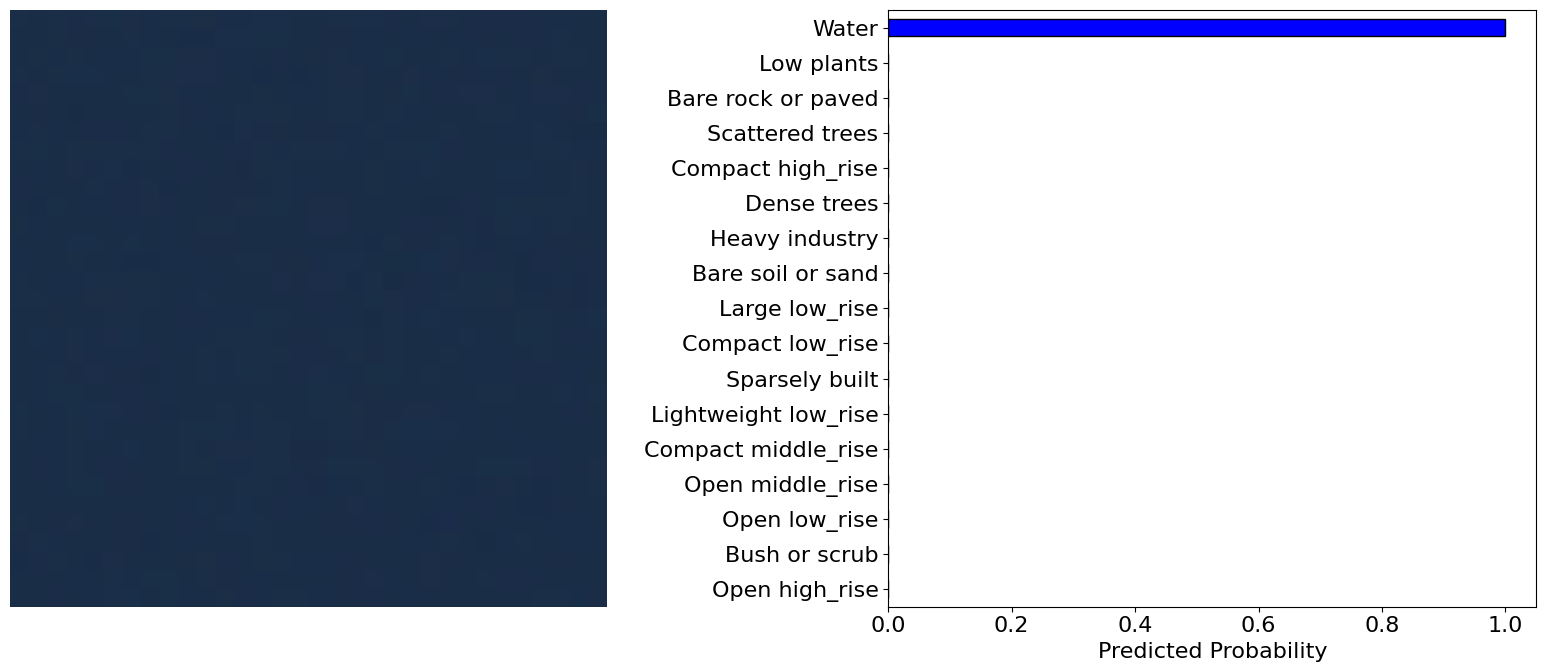

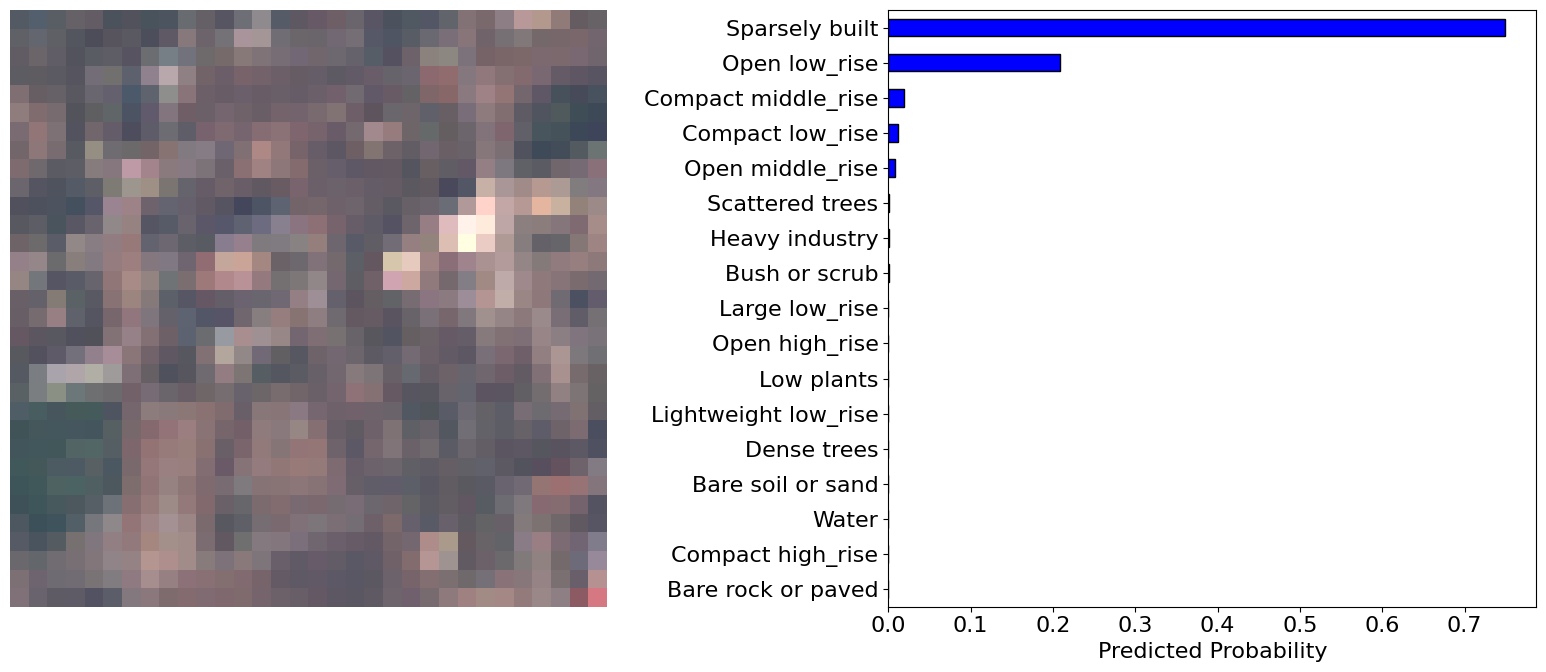

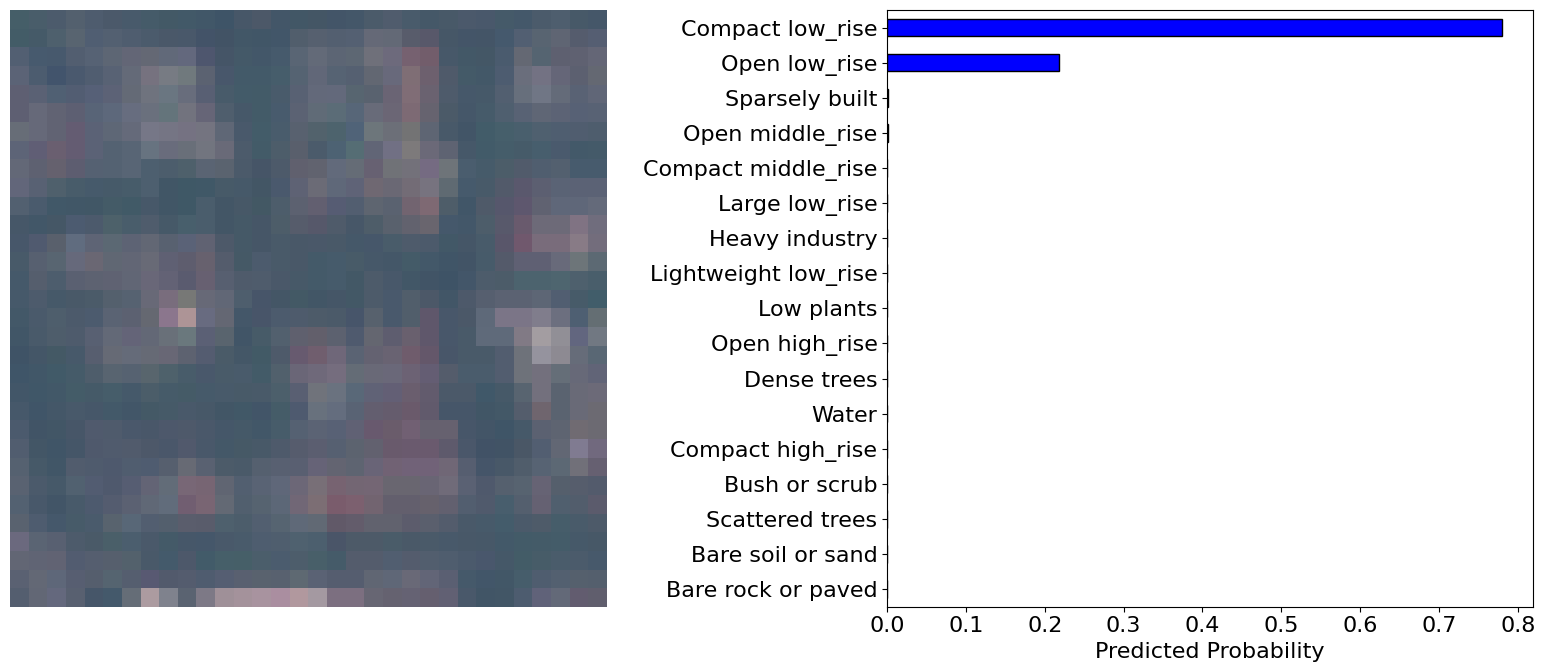

In [12]:
labels = ["Compact high_rise",
    "Compact middle_rise",
    "Compact low_rise",
    "Open high_rise",
    "Open middle_rise",
    "Open low_rise",
    "Lightweight low_rise",
    "Large low_rise",
    "Sparsely built",
    "Heavy industry",
    "Dense trees",
    "Scattered trees",
    "Bush or scrub",
    "Low plants",
    "Bare rock or paved",
    "Bare soil or sand",
    "Water"]
transform = ResizeCenterCropToTensor()

model_path = "/home/dragik/data/experiments/so2sat/checkpoint.pth.tar"
model.load_model(model_path)

test_dataset_config = {
    "h5_file": "/home/dragik/data/So2Sat/testing.h5",
}

test_dataset = So2SatDataset(test_dataset_config)
print(f'The amount of images for testing is {len(test_dataset)}')

image = test_dataset[0][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[10][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[100][0]
fig = model.predict_image(image, labels, transform)